In [1]:
from GenNetwork import Generator, Discriminator, GAN
import argparse
import numpy as np

2025-07-26 17:13:15.265648: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753542795.286245  916588 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753542795.292642  916588 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-26 17:13:15.313841: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
generator = Generator(latent_dim=128, n_units=256, n_layers=3)
discriminator = Discriminator(input_shape=(36, 1), n_units=256, n_layers=3, dropout=0.3)
gan = GAN(generator, discriminator, latent_dim=128)

--- Generator Architecture ---


2025-07-26 17:13:23.699198: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        32,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        65,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        65,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 36)             │         9,252 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 36, 1)          │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 176,164 (688.14 KB)

...

Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 36, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │         9,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 141,313 (552.00 KB)

 Trainable params: 141,313 (552.00 KB)

 Non-trainable params: 0 (0.00 B)

In [3]:
#training data 

data = np.random.normal(size=(100000, 36, 1))  # Example training data
data = (data - data.min(axis=0)) / (data.max(axis=0) - data.min(axis=0))  # Normalize data
data = data.astype(np.float32)


In [4]:
import tensorflow as tf
data_tf = tf.data.Dataset.from_tensor_slices(data)
data_tf = data_tf.shuffle(buffer_size=32).batch(32).prefetch(tf.data.AUTOTUNE)

In [5]:
gan.compile(g_optimizer = generator.optimizer, d_optimizer = discriminator.optimizer)
history = gan.fit(data_tf, epochs=10, batch_size=32)

Epoch 1/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 33s 9ms/step - discriminator_loss: -0.3423 - generator_loss: 0.4050
Epoch 2/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - discriminator_loss: -0.1620 - generator_loss: 0.6558
Epoch 3/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - discriminator_loss: -0.1131 - generator_loss: 1.7981
Epoch 4/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - discriminator_loss: -0.0980 - generator_loss: 1.7690
Epoch 5/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - discriminator_loss: -0.0988 - generator_loss: 0.6877
Epoch 6/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - discriminator_loss: -0.0846 - generator_loss: 0.2057
Epoch 7/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - discriminator_loss: -0.0788 - generator_loss: 0.3359
Epoch 8/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - discriminator_loss: -0.0794 - generator_loss: 0.2518
Epoch 9/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - discriminator_loss: -0.0738 - generator_loss: 0.0628
Epoch 10/1

In [6]:
# Your generator's latent dimension (the size of the noise vector)
LATENT_DIM = 128

# 1. Define how many new samples you want to create.
num_new_samples = 1000000

# 2. Create a TENSOR of random noise with the correct input shape.
# Shape should be: (number_of_samples, latent_dimension)
noise_input = tf.random.normal([num_new_samples, LATENT_DIM])

# 3. Pass this TENSOR of noise to the generator model for inference.
generated_data = generator.model(noise_input, training=False)
generated_data_np = generated_data.numpy()
min_original_data = data.min(axis=0)
max_original_data = data.max(axis=0)

# 4. Rescale the generated data to the original data's range.
generated_data_rescaled = (generated_data_np + 1) / 2 * (max_original_data - min_original_data) + min_original_data


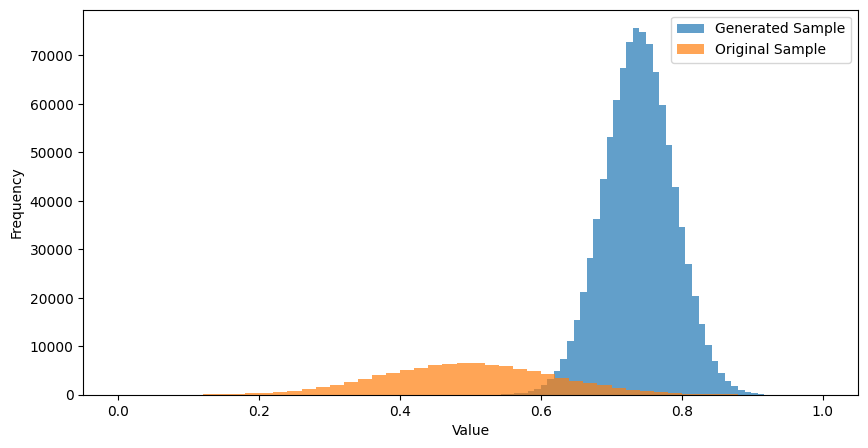

In [10]:
#plot genarated data
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.hist(generated_data_rescaled[:, 0, 0], bins=50, label='Generated Sample', alpha=0.7)
plt.hist(data[:, 0, 0], bins=50, label='Original Sample', alpha=0.7)
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()
plt.show()